# Embedding Analysis

Quick sanity checks for image embeddings (PCA scatter plots etc.).

In [ ]:
import sys
import numpy as np
import umap
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA

sys.path.insert(0, str(Path('..') / 'src'))
from config import EMBEDDINGS_DIR

embeddings_path = EMBEDDINGS_DIR / 'image_embeddings.npy'
metadata_path = EMBEDDINGS_DIR / 'embedding_metadata.csv'

embeddings = np.load(embeddings_path)
metadata = pd.read_csv(metadata_path)

print('Embeddings shape:', embeddings.shape)
print('Metadata shape:', metadata.shape)

c:\Users\Yeva\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Embeddings shape: (1500, 2048)
Metadata shape: (1500, 11)


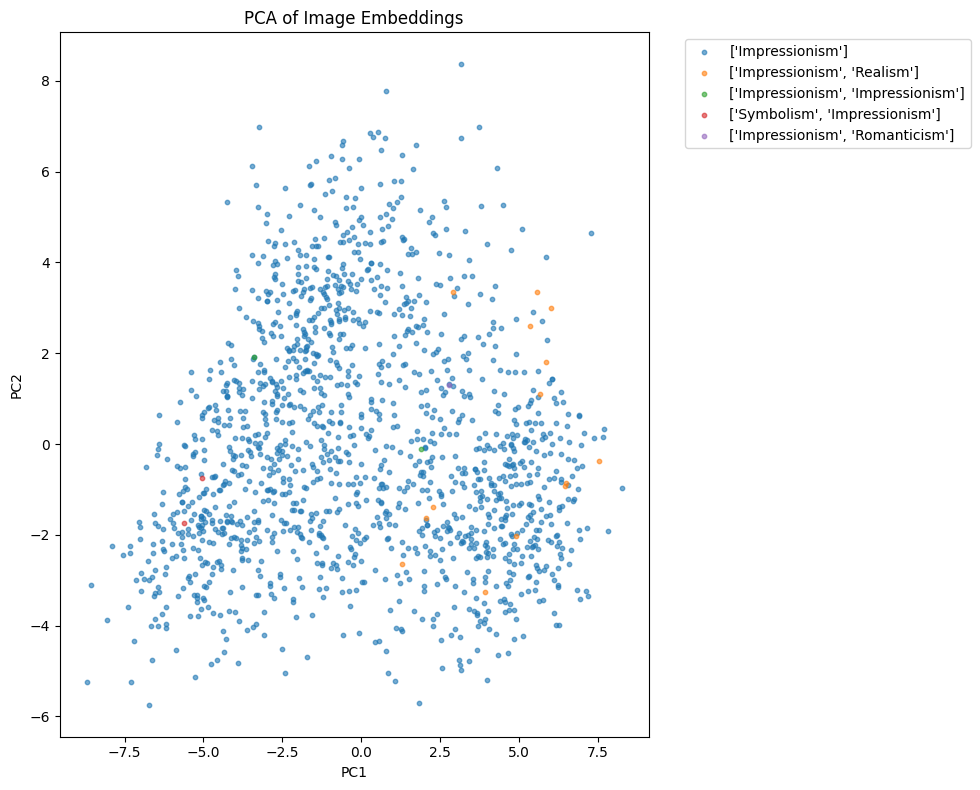

In [2]:
"""
Basic PCA to 2D and scatter plot colored by genre (if available).
"""
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
if 'genre' in metadata.columns:
    genres = metadata['genre'].astype(str)
    unique_genres = genres.unique()
    for g in unique_genres:
        mask = genres == g
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=10, label=g, alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=10, alpha=0.6)

plt.title('PCA of Image Embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

c:\Users\Yeva\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


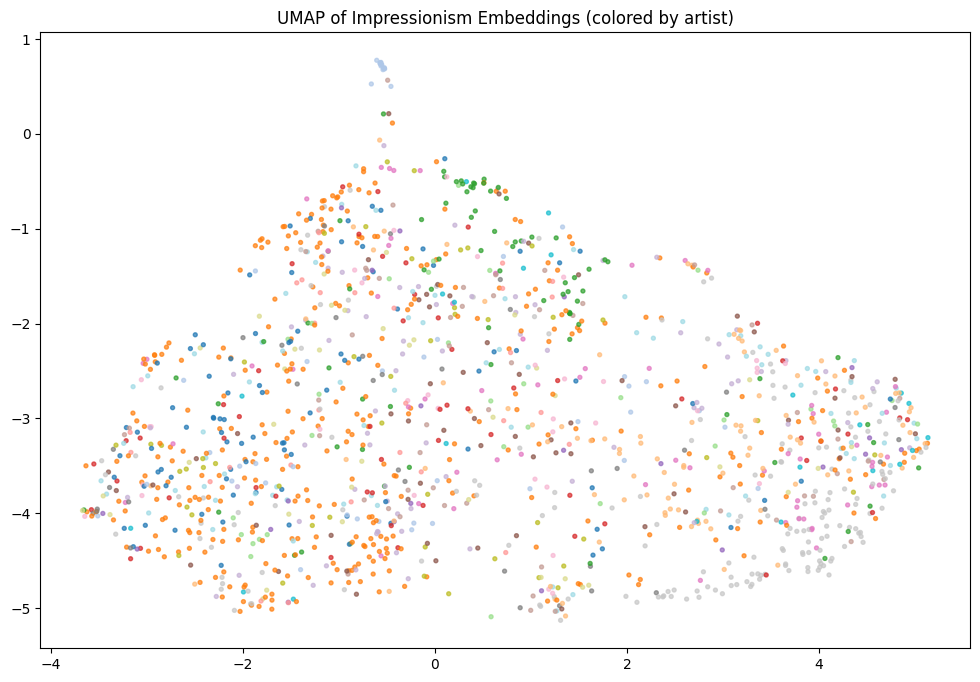

In [3]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords = reducer.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
# Color by artist to see if structure emerges
artists = metadata['artist'].astype('category')
scatter = plt.scatter(coords[:,0], coords[:,1], 
                      c=artists.cat.codes, cmap='tab20', 
                      s=8, alpha=0.7)
plt.title('UMAP of Impressionism Embeddings (colored by artist)')
plt.savefig('umap_by_artist.png', dpi=150)